<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Lesson_04/INFO648Lesson4_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Descriptive Statistics and Trailing Indicators

### What Are Descriptive Statistics?

**Descriptive statistics** are numerical summaries that describe the main features of a dataset.
They help us understand what the data *look like* by summarizing:

- Typical values (mean, median)
- Spread or variability (standard deviation, quartiles)
- Extremes and outliers (minimum, maximum)

Descriptive statistics do **not** explain *why* something happened and do **not** predict the future.
They only summarize what has already occurred in the observed data.

---

### Descriptive Statistics as Trailing Indicators

A **trailing indicator** is a measure that reflects past outcomes rather than future events.

Descriptive statistics are **trailing indicators** because:
- They are calculated from **historical data**
- They summarize **completed behavior**
- They change *after* the underlying activity has already happened

For example:
- Median weekly earnings summarize earnings that workers already received
- Average hours worked summarize hours that were already worked
- Standard deviation reflects past variation, not future uncertainty

---

### What Descriptive Statistics Can and Cannot Do

**They can:**
- Describe typical outcomes
- Reveal variability and inequality
- Highlight patterns and anomalies in the data

**They cannot:**
- Identify causes
- Make forecasts
- Evaluate policy effects or interventions

Understanding descriptive statistics as trailing indicators helps prevent over-interpretation and
sets the stage for more advanced analysis, such as modeling or prediction.

---

### Key Takeaway

**Descriptive statistics tell us what happened, not why it happened or what will happen next.**

They are essential first steps in data analysis, but they must be interpreted within the context
of how the data were generated and collected.


In [1]:
import pandas as pd

In [2]:
# This is a pretty large data set - I put it in a google bucket and it is much faster for you to bring it into your environment.
!wget https://storage.googleapis.com/info648_bucket/cps_00010.csv


--2026-05-21 00:10:55--  https://storage.googleapis.com/info648_bucket/cps_00010.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.217.207, 108.177.11.207, 108.177.12.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.217.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 609667060 (581M) [text/csv]
Saving to: ‘cps_00010.csv’

cps_00010.csv       100%[===================>] 581.42M  31.4MB/s    in 6.7s    

2026-05-21 00:11:02 (86.6 MB/s) - ‘cps_00010.csv’ saved [609667060/609667060]



In [3]:
df=pd.read_csv("cps_00010.csv")

In [6]:
df.head()
df.shape

(5553935, 19)

In [18]:
df=df[(df["EARNWEEK2"]<9999)&
   (df["EARNWEEK2"] > 0)]

def classify_education_cps(educ):
    """
    CPS EDUC variable (0–125 scale)
    """
    if educ is None:
        return None

    try:
        educ = int(educ)
    except (ValueError, TypeError):
        return None

    # Not in universe / children
    if educ <= 2:
        return "NIU / Child"

    # Less than high school
    if educ < 71:
        return "Less than HS"

    # High school diploma
    if educ == 71:
        return "High School"

    # Some college (no degree)
    if educ == 73:
        return "Some College"

    # Associate degree
    if 80 <= educ < 90:
        return "Associate's"

    # Bachelor's degree
    if 90 <= educ < 100:
        return "Bachelor's"

    # Master's degree
    if 110 <= educ < 120:
        return "Master's"

    # Professional or Doctorate
    if educ >= 120:
        return "Graduate / Professional"

    return "Unknown"



df["education"] = df["EDUC"].apply(classify_education_cps)


# CPS Data Dictionary (Teaching Version)

This dataset comes from the **Current Population Survey (CPS)** and is used to illustrate
**descriptive statistics** using labor and earnings data.

---

## Identification & Survey Structure  
*(Survey mechanics – not used for analysis in this notebook)*

**YEAR**  
- Survey year  
- Used for time-based grouping

**MONTH**  
- Survey month (1–12)  
- Not used in this analysis

**SERIAL**  
- Household identifier  
- Used to link people within a household

**PERNUM**  
- Person number within household

**CPSID**  
- Unique household identifier across CPS samples

**CPSIDP**  
- Unique person identifier across CPS samples

**CPSIDV**  
- CPS version identifier

---

## Survey Weights  
*(Important for official estimates, not used in this lesson)*

**WTFINL**  
- Final person weight

**HWTFINL**  
- Household weight

**ASECWT**  
- ASEC supplement person weight

**ASECWTH**  
- ASEC household weight

**ASECFLAG**  
- Indicates participation in the ASEC income supplement

---

## Geography

**STATEFIP**  
- State FIPS code (1–56)  
- Example: 51 = Virginia, 9 = Connecticut  
- Used only for state-level comparisons

---

## Demographics

**AGE**  
- Age in years  
- Used to restrict to working-age population

**SEX**  
- Sex of respondent  
  - 1 = Male  
  - 2 = Female  

---

## Labor & Earnings Variables (Core to This Notebook)

**UHRSWORKT**  
- *Usual hours worked per week*  
- Special code:  
  - `999` = Not in universe / not reported  
- Notes:  
  - Strong heaping at 40 hours  
  - Rounded responses are common  

**EARNWEEK2**  
- *Usual weekly earnings*  
- Special codes:  
  - `0` = Not applicable / not reported  
  - Very large values (e.g., ≥ 100000 or 1,000,000) = Top-coded  
- Notes:  
  - Mixture of hourly and salaried workers  
  - Highly right-skewed distribution  

---

## Variables Used in This Analysis

For this lesson on **descriptive statistics**, we focus on:

- `YEAR`
- `UHRSWORKT`
- `EARNWEEK2`
- `AGE`
- `STATEFIP` (optional)

All other variables are survey mechanics and are dropped to keep the analysis focused.

---

**Key takeaway:**  
Most CPS variables exist to run the survey correctly.  
Only a small subset are needed to answer analytical questions.


In [19]:
df.shape

(537501, 20)

Let's make this a smaller workbook.

In [20]:
df_analyze=df[['YEAR','UHRSWORKT','EARNWEEK2','AGE','SEX','STATEFIP']].copy()

In [21]:
df_analyze.describe()

,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,537501.000000,537501.000000,537501.000000,537501.000000,537501.000000,537501.000000
mean,2023.276969,87.280035,1268.045212,42.584974,1.490635,28.256950
std,1.230717,209.648805,1100.474649,14.673513,0.499913,16.239237
min,2020.000000,0.000000,4.000000,0.000000,1.000000,1.000000
25%,2022.000000,40.000000,634.000000,31.000000,1.000000,13.000000
50%,2023.000000,40.000000,1000.000000,42.000000,1.000000,29.000000
75%,2024.000000,40.000000,1600.000000,54.000000,2.000000,42.000000
max,2025.000000,999.000000,9918.000000,85.000000,2.000000,56.000000


df.loc[ROW_SELECTION, COLUMN_SELECTION]

In [22]:
df_clean=df_analyze[(df_analyze['UHRSWORKT'].between(1,80)) & (df_analyze['AGE']>=18)].copy()
df_clean.loc[df_clean['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
df_clean.loc[df_clean['EARNWEEK2']<1,'EARNWEEK2']=pd.NA


In [23]:
df_clean.describe()

,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,501023.000000,501023.000000,501023.000000,501023.000000,501023.000000,501023.000000
mean,2023.278953,39.282223,1292.751091,42.977564,1.491301,28.186199
std,1.231063,9.731452,1094.765333,14.308283,0.499925,16.264546
min,2020.000000,1.000000,4.000000,18.000000,1.000000,1.000000
25%,2022.000000,40.000000,662.000000,31.000000,1.000000,13.000000
50%,2023.000000,40.000000,1000.000000,42.000000,1.000000,29.000000
75%,2024.000000,40.000000,1620.000000,54.000000,2.000000,42.000000
max,2025.000000,80.000000,9918.000000,85.000000,2.000000,56.000000


# Tukeys 5 -*Goto Slides*

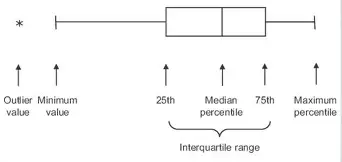

<Axes: >

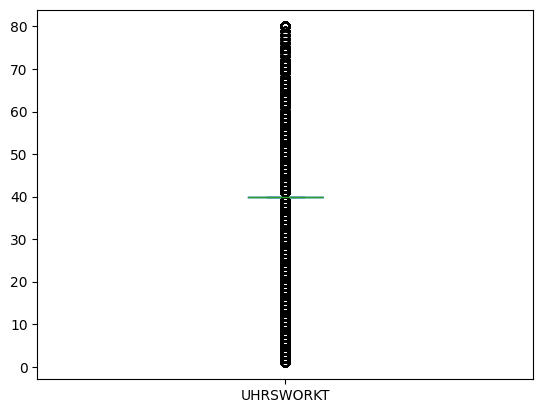

In [24]:
#We begin with Tukey’s five-number summary to understand the *distribution* of hours worked
#before discussing averages or variability.
#Tukey 5 code
df_clean['UHRSWORKT'].quantile([0,.25,.5,.75,1])
#Box plot code
df_clean["UHRSWORKT"].plot(kind='box')

“If the middle of the data barely varies, do you think variability is small?


This pattern happens when:

People round to focal numbers (40)

But real variation exists in:

part-time work

overtime

multiple jobs

We just want people who worked and reported hours

In [ ]:
# Lets do the tukey 5 and  box plot of those who worked more or less than 40 hours


#Standard deviation measures how far observations tend to be from the mean.
#*Go to slides*

It is sensitive to values in the tails of the distribution,
even when the middle of the data is tightly clustered.


In [25]:
#Compute the mean for hours worked - Compare this to the median
df_clean['UHRSWORKT'].mean()
df_clean['UHRSWORKT'].std()

9.731452013426562

Interesting the IQR is 0, however the standard deviation is 9.7 hours.

In [ ]:
#Compute the standard deviation for hours worked - compare this to the IQR


In [27]:
#Let's see if this changes at all by year?
df_clean.groupby(["YEAR"])['UHRSWORKT'].agg(['count', 'mean', 'std', 'median']).reset_index()

,YEAR,count,mean,std,median
0,2020,10916,39.163705,10.066178,40.0
1,2021,10480,39.313645,9.618201,40.0
2,2022,130687,39.546206,9.705138,40.0
3,2023,126426,39.367211,9.657094,40.0
4,2024,120871,39.110688,9.748163,40.0
5,2025,101643,39.050569,9.802804,40.0




“Tukey tells us what’s typical.
Standard deviation tells us how unequal experiences are.
Both are trailing indicators — they summarize what already happened.”

You’ve now:

Used real data

Created a puzzle

Resolved it cleanly

Reinforced why multiple statistics are necessary

Correlation measures the strength of a linear relationship between two variables. It is a value between -1 and 1. 1 means perfectly correlated (Think ice cream sales and temperature) and -1 means negatively correlated (Think more time driving and fuel level in your car).

It **does not**  imply causation and does not explain why the relationship exists.

Here, we examine whether people who work more hours tend to earn more per week.


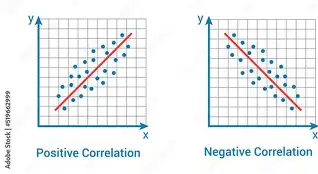

In [28]:
# Let's find the correlation between hours worked and earnings
#we should remove NAs as they seem to gunk up the execution.

df_corr = df_clean.dropna(subset=['UHRSWORKT', 'EARNWEEK2'])
df_corr[['UHRSWORKT', 'EARNWEEK2']].corr()



,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.337591
EARNWEEK2,0.337591,1.000000


<Axes: xlabel='UHRSWORKT', ylabel='EARNWEEK2'>

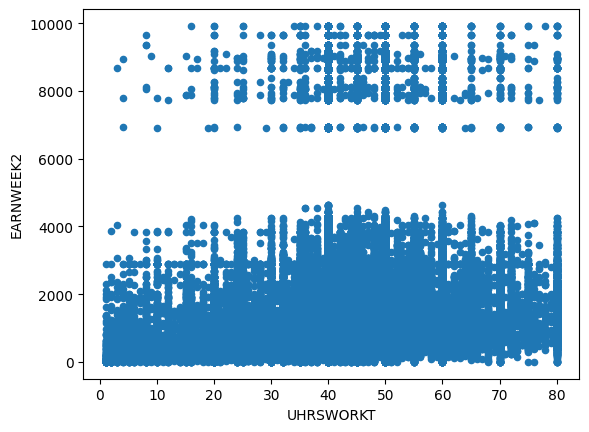

In [29]:
#We often use a scatter plot to see correlation. Make sure I discuss heaping.
#Discuss the split in the data
df_corr.plot(kind="scatter",x="UHRSWORKT",y="EARNWEEK2")

Lets discuss multimodal vs outliers and why it is good to understand the problem and not just chop the "outliers".

In [30]:
#Multimodal vs outliers.
df_workers = df_corr[df_clean['EARNWEEK2'] < 6000]
df_workers[['UHRSWORKT', 'EARNWEEK2']].corr()

,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.414215
EARNWEEK2,0.414215,1.000000


<Axes: xlabel='UHRSWORKT', ylabel='EARNWEEK2'>

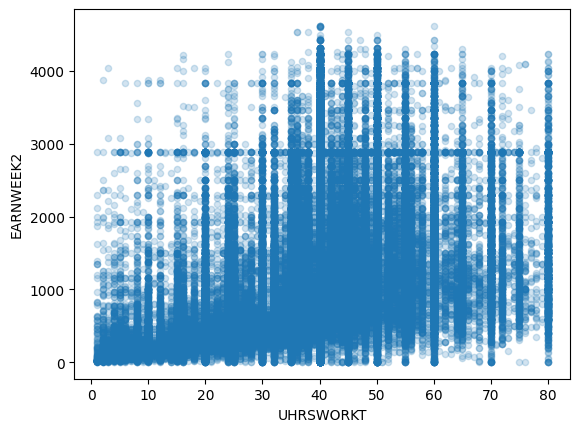

In [31]:
#now make the scatter plot
df_workers.plot(kind="scatter",x="UHRSWORKT",y="EARNWEEK2", alpha=.2)

In [36]:
# Lets look at the state level - maybe we can clean up the noise.
ct=df_workers[df_workers['STATEFIP']==9]
ct['EARNWEEK2'].corr(ct['UHRSWORKT'])
wv=df_workers[df_workers['STATEFIP']==28]
wv['EARNWEEK2'].corr(wv['UHRSWORKT'])
# ct.plot(kind="scatter",y='EARNWEEK2',x='UHRSWORKT')
# wv.plot(kind="scatter",y='EARNWEEK2',x='UHRSWORKT')


np.float64(0.35975083806717817)